# Fase 3 Projeto FIAP

## Visualização dos dados

In [11]:
# Data visualization library
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")
df.head(5)

/var/folders/h0/9cxt3flx6px_mz8j5myq3cjw0000gn/T/ipykernel_85726/3454041049.py:1: DtypeWarning: Columns (4,5,31,32,33,34,37,38,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/silver/flights_delay_cancelled.csv", sep=",")


,DAY_OF_WEEK,AIRLANE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,...,ORIGIN_STATE_NAME,ORIGIN_COUNTRY_NAME,ORIGIN_LATITUDE_NAME,ORIGIN_LONGITUDE_NAME,DESTINATION_AIRPORT_NAME,DESTINATION_CITY_NAME,DESTINATION_STATE_NAME,DESTINATION_COUNTRY_NAME,DESTINATION_LATITUDE_NAME,DESTINATION_LONGITUDE_NAME
0,4,AS,98,N407AS,ANC,SEA,5,2354,-11.0,21.0,...,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,4,AA,2336,N3KUAA,LAX,PBI,10,2,-8.0,12.0,...,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,4,US,840,N171US,SFO,CLT,20,18,-2.0,16.0,...,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,4,AA,258,N3HYAA,LAX,MIA,20,15,-5.0,15.0,...,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,4,AS,135,N527AS,SEA,ANC,25,24,-1.0,11.0,...,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


In [13]:
df.columns

Index(['DAY_OF_WEEK', 'AIRLANE_CODE', 'FLIGHT_NUMBER', 'TAIL_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_IN', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED',
       'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
       'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DATE',
       'DISTANCE_KM', 'CANCELLATION_DESCRIPTION', 'WEEKDAY_NAME',
       'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY_NAME',
       'ORIGIN_STATE_NAME', 'ORIGIN_COUNTRY_NAME', 'ORIGIN_LATITUDE_NAME',
       'ORIGIN_LONGITUDE_NAME', 'DESTINATION_AIRPORT_NAME',
       'DESTINATION_CITY_NAME', 'DESTINATION_STATE_NAME',
       'DESTINATION_COUNTRY_NAME', 'DESTINATION_LATITUDE_NAME',
       'DESTINATION_LONGITUDE_NAME'],
      dtype='object')

----

#### Atraso por dia da Semana

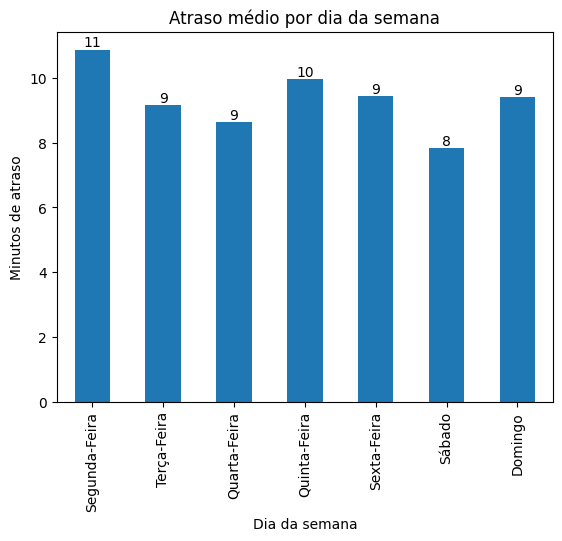

In [19]:
map_dias = {
    1: 'Segunda-Feira',
    2: 'Terça-Feira',
    3: 'Quarta-Feira',
    4: 'Quinta-Feira',
    5: 'Sexta-Feira',
    6: 'Sábado',
    7: 'Domingo'
}

serie = (
    df.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY']
      .mean()
      .rename(index=map_dias)
)

ax = serie.plot(kind='bar')

plt.title('Atraso médio por dia da semana')
plt.ylabel('Minutos de atraso')
plt.xlabel('Dia da semana')

# Rótulos de dados
for i, v in enumerate(serie.values):
    ax.text(
        i,
        v,
        f'{v:.0f}',
        ha='center',
        va='bottom'
    )

plt.show()


----

In [ ]:
df['SCHEDULED_TIME_HOUR'] = pd.to_datetime(
    df['SCHEDULED_DEPARTURE'].astype(str).str.zfill(4),
    format='%H%M'
)

0         1900-01-01 00:05:00
1         1900-01-01 00:10:00
2         1900-01-01 00:20:00
3         1900-01-01 00:20:00
4         1900-01-01 00:25:00
                  ...        
5819074   1900-01-01 23:59:00
5819075   1900-01-01 23:59:00
5819076   1900-01-01 23:59:00
5819077   1900-01-01 23:59:00
5819078   1900-01-01 23:59:00
Name: SCHEDULED_TIME_HOUR, Length: 5819079, dtype: datetime64[ns]

In [23]:
df['HOUR'] = df['SCHEDULED_TIME_HOUR'].dt.hour
df['HOUR']

0           0
1           0
2           0
3           0
4           0
           ..
5819074    23
5819075    23
5819076    23
5819077    23
5819078    23
Name: HOUR, Length: 5819079, dtype: int32

In [25]:
group_by_hour = df.groupby('HOUR')['DEPARTURE_DELAY'].mean()
group_by_hour

HOUR
0      7.199849
1      8.086939
2      7.266955
3      8.917862
4     10.335227
5      1.897017
6      2.106578
7      3.252010
8      4.685878
9      5.677080
10     6.894669
11     7.783086
12     8.953613
13     9.796986
14    11.178353
15    11.941296
16    12.931783
17    13.836957
18    14.989270
19    15.075731
20    15.292740
21    13.715801
22    11.771036
23     9.518519
Name: DEPARTURE_DELAY, dtype: float64

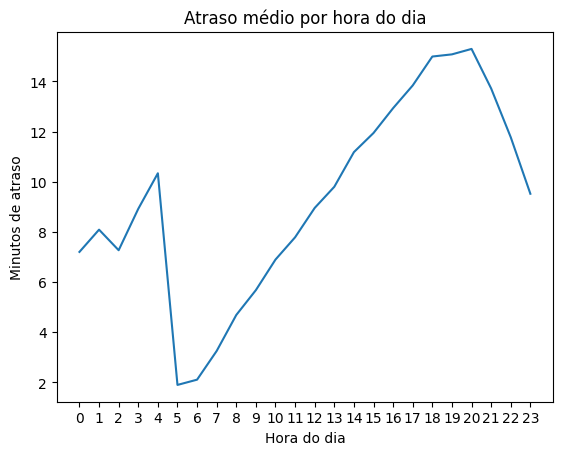

In [24]:
serie = df.groupby('HOUR')['DEPARTURE_DELAY'].mean()

ax = serie.plot()
plt.title('Atraso médio por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Minutos de atraso')
plt.xticks(range(0, 24))
plt.show()


- Geralmente a média de atrasos por hora do dia acontece nos horarios:
    - 18:00
    - 19:00
    - 20:00

- Podendo chegar a conclusão que por conta do horario de pico na cidade, alguns passageiros podem se atrasar por vários fatores, sendo eles fila de despache alto, transito para chegar no aeroporto, altas filas para o raio-x e entre outras vários fatores

----

#### Analise por Companhia Aérea

In [27]:
group_by_airline = df.groupby('AIRLANE_CODE')['DEPARTURE_DELAY'].mean().sort_values()
group_by_airline

AIRLANE_CODE
HA     0.485713
AS     1.785801
US     6.141137
DL     7.369254
OO     7.801104
EV     8.715934
AA     8.900856
VX     9.022595
MQ    10.125188
WN    10.581986
B6    11.514353
F9    13.350858
UA    14.435441
NK    15.944766
Name: DEPARTURE_DELAY, dtype: float64

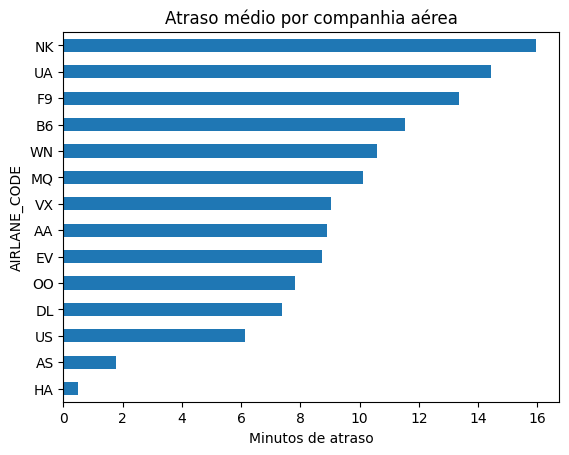

In [29]:
ax = group_by_airline.plot(kind='barh')
plt.title('Atraso médio por companhia aérea')
plt.xlabel('Minutos de atraso')
plt.show()


---

#### Correlação entre Taxeamento x Atraso na decolagem

In [30]:
correlacao = df[['TAXI_OUT', 'DEPARTURE_DELAY']].corr()
correlacao

,TAXI_OUT,DEPARTURE_DELAY
TAXI_OUT,1.000000,0.058515
DEPARTURE_DELAY,0.058515,1.000000


- Se o taxi out aumenta, o atraso na decolagem tende aumentar junto, ou seja, tem uma correlação forte esses dois tipos de dados

---

#### Atraso Médio por Origem e por Destino

In [36]:
"""
Relação de média de atraso na partida por Estados
"""

origin = (
    df.groupby(['ORIGIN_CITY_NAME', 'ORIGIN_STATE_NAME'])
      .agg(dep_delay_mean=('DEPARTURE_DELAY', 'mean'))
      .reset_index()
)

origin

,ORIGIN_CITY_NAME,ORIGIN_STATE_NAME,dep_delay_mean
0,Aberdeen,SD,10.101056
1,Abilene,TX,5.783989
2,Adak,AK,10.662921
3,Agana,GU,16.647590
4,Aguadilla,PR,12.376126
...,...,...,...
313,Windsor Locks,CT,7.605954
314,Worcester,MA,5.526646
315,Wrangell,AK,3.091884
316,Yakutat,AK,-6.292237


In [37]:
"""
Relação de média de atraso na chegada por Estados
"""

destiny = (
    df.groupby(['DESTINATION_CITY_NAME', 'DESTINATION_STATE_NAME'])
      .agg(arr_delay_mean=('ARRIVAL_DELAY', 'mean'))
      .reset_index()
)
destiny

,DESTINATION_CITY_NAME,DESTINATION_STATE_NAME,arr_delay_mean
0,Aberdeen,SD,-3.389650
1,Abilene,TX,4.081385
2,Adak,AK,-3.191011
3,Agana,GU,17.320242
4,Aguadilla,PR,12.192771
...,...,...,...
313,Windsor Locks,CT,6.599109
314,Worcester,MA,0.488994
315,Wrangell,AK,5.375767
316,Yakutat,AK,0.371166


In [38]:
origin = origin.rename(columns={
    'ORIGIN_CITY_NAME': 'CITY',
    'ORIGIN_STATE_NAME': 'STATE'
})

destiny = destiny.rename(columns={
    'DESTINATION_CITY_NAME': 'CITY',
    'DESTINATION_STATE_NAME': 'STATE'
})

In [41]:
city_delays = origin.merge(
    destiny,
    on=['CITY', 'STATE'],
    how='inner'
)

In [45]:
city_delays

,CITY,STATE,dep_delay_mean,arr_delay_mean
0,Aberdeen,SD,10.101056,-3.389650
1,Abilene,TX,5.783989,4.081385
2,Adak,AK,10.662921,-3.191011
3,Agana,GU,16.647590,17.320242
4,Aguadilla,PR,12.376126,12.192771
...,...,...,...,...
313,Windsor Locks,CT,7.605954,6.599109
314,Worcester,MA,5.526646,0.488994
315,Wrangell,AK,3.091884,5.375767
316,Yakutat,AK,-6.292237,0.371166


In [43]:
correlacao_city_delays = city_delays[['dep_delay_mean', 'arr_delay_mean']].corr()
correlacao_city_delays

,dep_delay_mean,arr_delay_mean
dep_delay_mean,1.000000,0.648842
arr_delay_mean,0.648842,1.000000


- Podemos chegar a conclusão que, possui uma correlação forte o atraso na saída e o atraso na chegada, porém não é um fator que seja definitivo, ou seja, pode a ver situações que aconteça um atraso na saída e um atraso na chegada, porém pode a ver um atraso na saída e o voo pode chegar no horario previsto, por isso justifica a correlação ser moderada/forte

In [47]:
group_city_delays = (
    city_delays
    .groupby("STATE")[["dep_delay_mean", "arr_delay_mean"]]
    .mean()
    .reset_index()
)

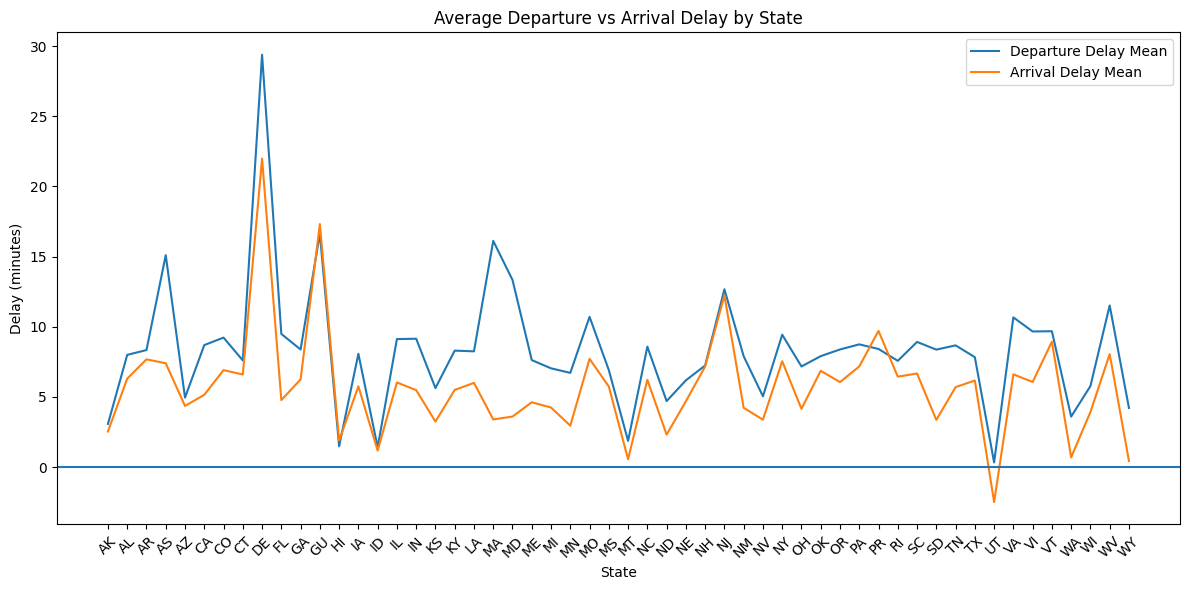

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(group_city_delays["STATE"], group_city_delays["dep_delay_mean"], label="Departure Delay Mean")
plt.plot(group_city_delays["STATE"], group_city_delays["arr_delay_mean"], label="Arrival Delay Mean")

plt.axhline(0)  # linha de referência (sem atraso)

plt.xlabel("State")
plt.ylabel("Delay (minutes)")
plt.title("Average Departure vs Arrival Delay by State")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Grafico acima podemos ver a correlação entre o atraso de partida dos voos e o atraso de chegada dos voos em cada estado

---

#### Quantidade de voos Cancelados por Categoria

In [ ]:
CANCELLED CANCELLATION_DESCRIPTION


group_by_cancelled = df.groupby(["CANCELLED", "CANCELLATION_DESCRIPTION"])["CANCELLATION_DESCRIPTION"]